In [1]:
using PyPlot
using JLD2
using Statistics

In [2]:
pathdir = "Y:/TwoDGas/2025/07/04"
N_atoms_center_drop = 1000

@load "Saved_exp_data/Imgs_croped_"*join(split(pathdir, "/")[3:end], "_")*".jld2" Sat τ_exp Imgs_atoms_crop_ds Imgs_bkg_crop_ds Imgs_dark_crop_ds
@load "Saved_exp_data/Droplets_"*join(split(pathdir, "/")[3:end], "_")*".jld2" centers_droplets_ds nbr_droplets_ds;

### Check validity of center droplet extraction

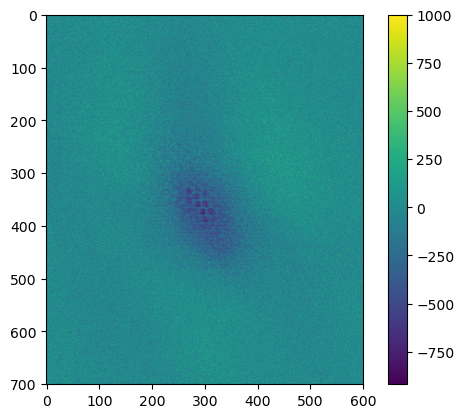

false

In [38]:
i, j = 1, 1

close("all")
fig = subplots()

copy_img = deepcopy(Imgs_atoms_crop_ds[i, j, :, :]-Imgs_bkg_crop_ds[i, j, :, :])
for centers in centers_droplets_ds[i][j]
    copy_img[round(Int, centers[2]), round(Int, centers[1])] = 1e3
end

img = imshow(copy_img)
colorbar(img)

# pygui(true); show()
pygui(false)

### Intensity at the center of the droplets

In [39]:
Iatoms_center_drop, Ibkg_center_drop, Idark_center_drop = zeros(size(Imgs_atoms_crop_ds)[1:2]), zeros(size(Imgs_atoms_crop_ds)[1:2]), zeros(size(Imgs_atoms_crop_ds)[1:2])

if length(τ_exp) == 1
    Convertion_factor = (0.85 * 0.107 * τ_exp)
end

for i = 1:length(Sat)
    if length(τ_exp) > 1
        Convertion_factor = (0.85 * 0.107 * τ_exp[i])
    end

    for j = 1:size(Imgs_atoms_crop_ds)[2]
        if nbr_droplets_ds[i, j] > 0
            for centers in centers_droplets_ds[i][j]
                Iatoms_center_drop[i, j] += Imgs_atoms_crop_ds[i, j, round(Int, centers[2]), round(Int, centers[1])]
                Ibkg_center_drop[i, j] += Imgs_bkg_crop_ds[i, j, round(Int, centers[2]), round(Int, centers[1])]
                Idark_center_drop[i, j] += Imgs_dark_crop_ds[i, j, round(Int, centers[2]), round(Int, centers[1])]
            end

            Iatoms_center_drop[i, j] /= nbr_droplets_ds[i, j]*Convertion_factor
            Ibkg_center_drop[i, j] /= nbr_droplets_ds[i, j]*Convertion_factor
            Idark_center_drop[i, j] /= nbr_droplets_ds[i, j]*Convertion_factor
        end
    end
end

### Compute mean/std

In [40]:
Mean_atoms, Mean_bkg, Mean_dark = zeros(length(Sat)), zeros(length(Sat)), zeros(length(Sat))
Std_atoms, Std_bkg, Std_dark = zeros(length(Sat)), zeros(length(Sat)), zeros(length(Sat))

for i = 1:length(Sat)
    atoms, bkg, dark = [], [], []
    for j = 1:size(Imgs_atoms_crop_ds)[2]
        if nbr_droplets_ds[i, j] > 0
            push!(atoms, Iatoms_center_drop[i, j]), push!(bkg, Ibkg_center_drop[i, j]), push!(dark, Idark_center_drop[i, j])
        end
    end
    Mean_atoms[i], Mean_bkg[i], Mean_dark[i] = mean(atoms), mean(bkg), mean(dark)
    Std_atoms[i], Std_bkg[i], Std_dark[i] = std(atoms), std(bkg), std(dark)
end

## Plots

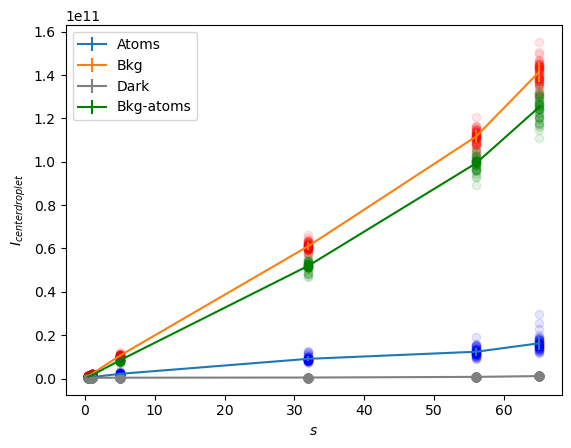

In [41]:
close("all")
fig = subplots()

errorbar(Sat, Mean_atoms, yerr=Std_atoms, label="Atoms")
errorbar(Sat, Mean_bkg, yerr=Std_bkg, label="Bkg")
errorbar(Sat, Mean_dark, yerr=Std_dark, label="Dark", color="grey")
errorbar(Sat, Mean_bkg-Mean_atoms, yerr=Std_dark, label="Bkg-atoms", color="g")


for i in 1:length(Sat)
    for j in 1:size(Imgs_atoms_crop_ds)[2]
        scatter(Sat[i], Iatoms_center_drop[i, j], color="b", alpha = 0.1)
        scatter(Sat[i], Ibkg_center_drop[i, j], color="r", alpha = 0.1)
        scatter(Sat[i], Idark_center_drop[i, j], color="grey")
        scatter(Sat[i], Ibkg_center_drop[i, j]-Iatoms_center_drop[i, j], color="g", alpha = 0.1)
    end
end

xlabel(L"s")
ylabel(L"I_{center droplet}")

legend()

# pygui(true); show();
pygui(false);

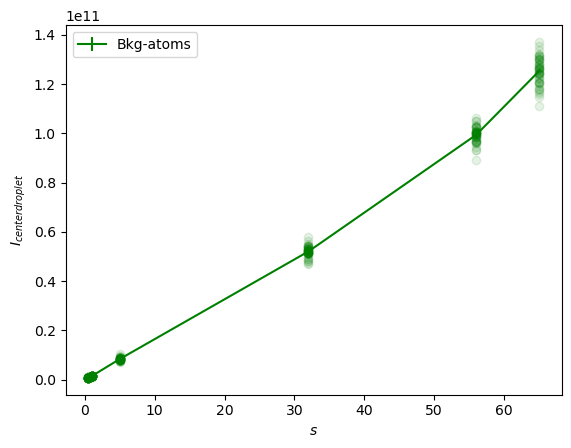

In [42]:
close("all")
fig = subplots()

errorbar(Sat, Mean_bkg-Mean_atoms, yerr=Std_dark, label="Bkg-atoms", color="g")

for i in 1:length(Sat)
    for j in 1:size(Imgs_atoms_crop_ds)[2]
        scatter(Sat[i], Ibkg_center_drop[i, j]-Iatoms_center_drop[i, j], color="g", alpha = 0.1)
    end
end

xlabel(L"s")
ylabel(L"I_{center droplet}")

legend()

# pygui(true); show();
pygui(false);

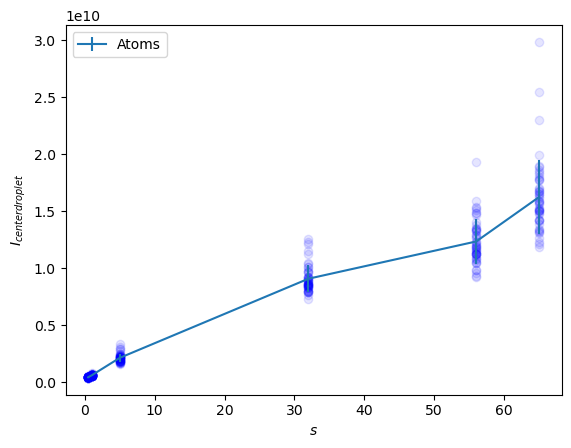

In [43]:
close("all")
fig = subplots()

errorbar(Sat, Mean_atoms, yerr=Std_atoms, label="Atoms")


for i in 1:length(Sat)
    for j in 1:size(Imgs_atoms_crop_ds)[2]
        scatter(Sat[i], Iatoms_center_drop[i, j], color="b", alpha = 0.1)
    end
end

xlabel(L"s")
ylabel(L"I_{center droplet}")

legend()

# pygui(true); show();
pygui(false);